In [ ]:
BASE_PATH = "data_dsmarket/data_dsmarket/"

import pandas as pd

pd_calendar = pd.read_csv(BASE_PATH + "daily_calendar_with_events.csv")
pd_prices = pd.read_csv(BASE_PATH + "item_prices.csv")
pd_sales = pd.read_csv(BASE_PATH + "item_sales.csv")

print("Datos cargados correctamente")
print(pd_sales.shape)

# DSMarket - Exploratory Data Analysis 
Proyecto Final - Nuclio Digital School

Este notebook realiza un EDA completo SIN usar melt para evitar problemas de memoria.

Incluye limpieza, análisis por tienda, festivos, días de la semana y categorías.


## 1️⃣ Librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

## 2️⃣ Carga de datos

In [5]:
calendar = pd.read_csv('data_dsmarket/data_dsmarket/daily_calendar_with_events.csv')
prices = pd.read_csv('data_dsmarket/data_dsmarket/item_prices.csv')
sales = pd.read_csv('data_dsmarket/data_dsmarket/item_sales.csv')

print("Datos cargados correctamente")

Datos cargados correctamente


## 3️⃣ Optimización de memoria

In [6]:
categorical_cols = ['item', 'category', 'department', 'store', 'store_code', 'region']

for col in categorical_cols:
    sales[col] = sales[col].astype('category')

day_cols = [col for col in sales.columns if col.startswith('d_')]
sales[day_cols] = sales[day_cols].astype('int16')

print("Memoria usada (MB):")
print(sales.memory_usage(deep=True).sum() / 1024**2)

Memoria usada (MB):
113.82175159454346


## 4️⃣ Limpieza de datos

In [7]:
# Eliminamos duplicados
sales = sales.drop_duplicates()
calendar = calendar.drop_duplicates()

# Nulos
print("Nulos en sales:", sales.isnull().sum().sum())
print("Nulos en calendar:")
print(calendar.isnull().sum())

# Ventas negativas
print("Ventas negativas:", (sales[day_cols] < 0).sum().sum())

Nulos en sales: 0
Nulos en calendar:
date              0
weekday           0
weekday_int       0
d                 0
event          1887
dtype: int64
Ventas negativas: 0


## 5️⃣ Ventas totales por día (sin melt)

In [8]:
daily_sales = sales[day_cols].sum()
daily_sales.index = daily_sales.index.str.replace('d_', '').astype(int)

calendar['d_num'] = calendar['d'].str.replace('d_', '').astype(int)

df_daily = pd.DataFrame({
    'd_num': daily_sales.index,
    'total_sales': daily_sales.values
})

df_daily = df_daily.merge(calendar, on='d_num', how='left')
df_daily['date'] = pd.to_datetime(df_daily['date'])

df_daily.head()

,d_num,total_sales,date,weekday,weekday_int,d,event
0,1,32631,2011-01-29,Saturday,1,d_1,NaN
1,2,31749,2011-01-30,Sunday,2,d_2,NaN
2,3,23783,2011-01-31,Monday,3,d_3,NaN
3,4,25412,2011-02-01,Tuesday,4,d_4,NaN
4,5,19146,2011-02-02,Wednesday,5,d_5,NaN


## 6️⃣ Análisis de Festivos por Tipo
Analizamos las ventas promedio según el tipo específico de evento.
Esto permite identificar qué festividades generan mayor impacto comercial.

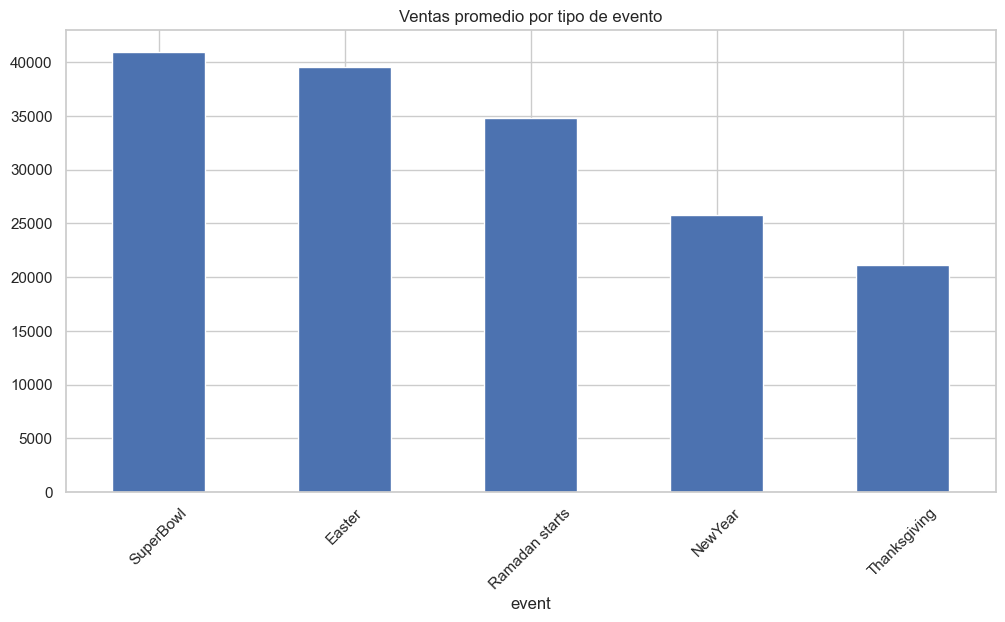

event
SuperBowl         40924.0
Easter            39517.6
Ramadan starts    34779.6
NewYear           25768.4
Thanksgiving      21130.0
Name: total_sales, dtype: float64

In [9]:
event_sales = df_daily.groupby('event')['total_sales'].mean().sort_values(ascending=False)

event_sales.plot(kind='bar', title="Ventas promedio por tipo de evento")
plt.xticks(rotation=45)
plt.show()

event_sales


Los eventos con mayores ventas suelen estar asociados a celebraciones (ej. Navidad, Acción de Gracias, etc.), donde aumenta el consumo.

Eventos con menor impacto pueden corresponder a días con menor actividad comercial o sin promociones asociadas.

Este análisis es clave para planificar campañas futuras y optimizar inventario.

## 7️⃣ Análisis por Día de la Semana
Identificamos qué días presentan mayor volumen de ventas promedio.

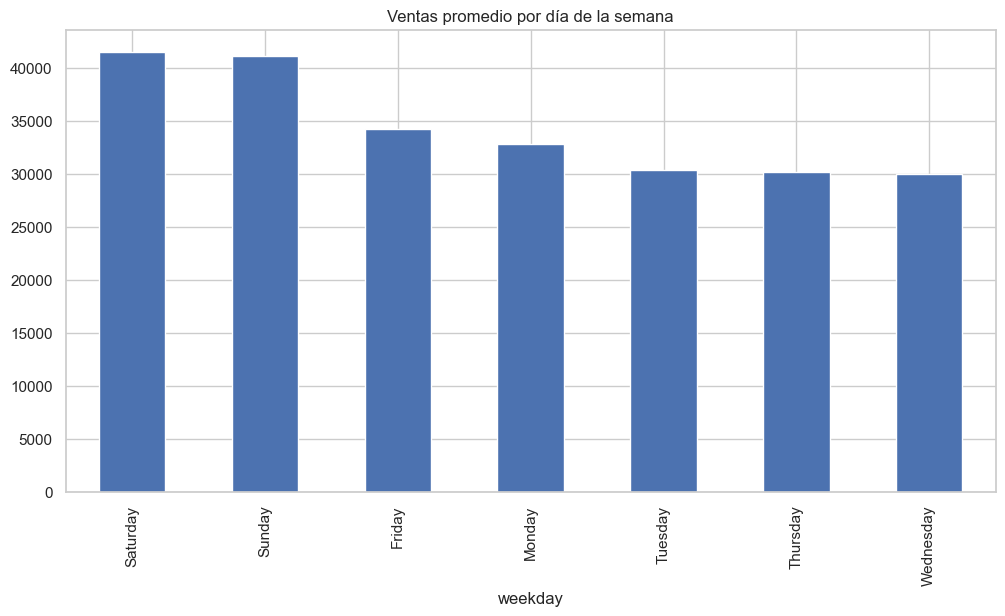

weekday
Saturday     41546.894161
Sunday       41130.021898
Friday       34225.985348
Monday       32852.967033
Tuesday      30368.780220
Thursday     30205.007326
Wednesday    30010.021978
Name: total_sales, dtype: float64

In [10]:
weekday_sales = df_daily.groupby('weekday')['total_sales'].mean().sort_values(ascending=False)

weekday_sales.plot(kind='bar', title="Ventas promedio por día de la semana")
plt.show()

weekday_sales


Normalmente los fines de semana concentran mayor volumen de ventas debido a mayor disponibilidad de tiempo de los consumidores.

Los días laborales pueden reflejar compras rutinarias o reposición.

## 8️⃣ Ventas totales por tienda

C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\266114651.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_sales = sales.groupby("store")[day_cols].sum().sum(axis=1).sort_values(ascending=False)


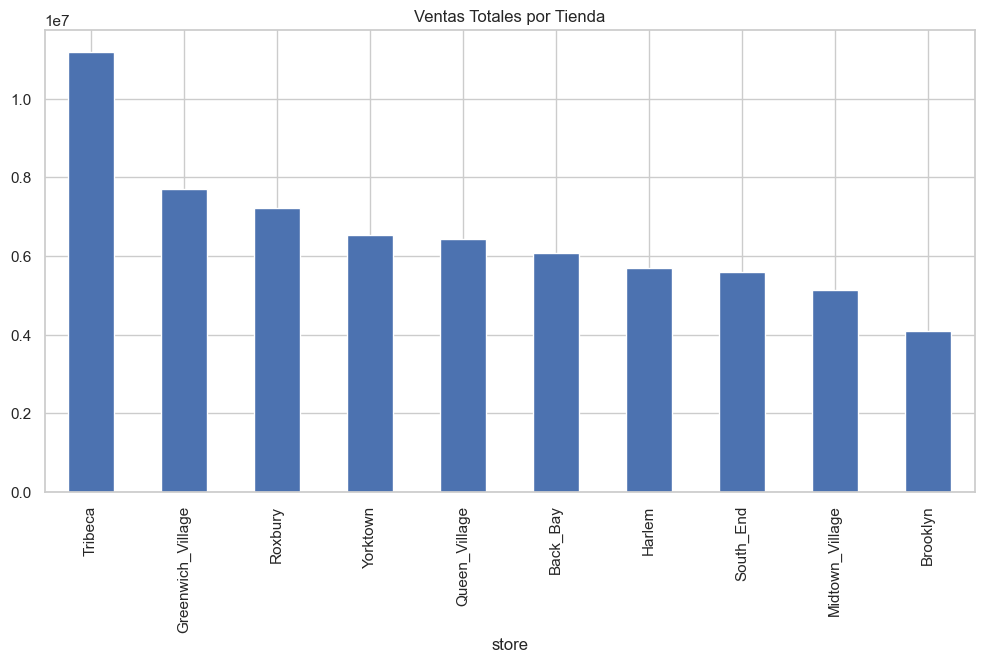

store
Tribeca              11188180
Greenwich_Village     7698216
Roxbury               7214384
Yorktown              6544012
Queen_Village         6427782
Back_Bay              6089330
Harlem                5685475
South_End             5595292
Midtown_Village       5149062
Brooklyn              4103676
dtype: int64

In [11]:
store_sales = sales.groupby("store")[day_cols].sum().sum(axis=1).sort_values(ascending=False)

store_sales.plot(kind='bar', title="Ventas Totales por Tienda")
plt.show()

store_sales


Las diferencias entre tiendas pueden deberse a ubicación geográfica, densidad poblacional o poder adquisitivo de la zona.

## 9️⃣ Análisis por Categoría de Producto
Evaluamos el rendimiento total por categoría.

C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\3135615099.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_sales = sales.groupby("category")[day_cols].sum().sum(axis=1).sort_values(ascending=False)


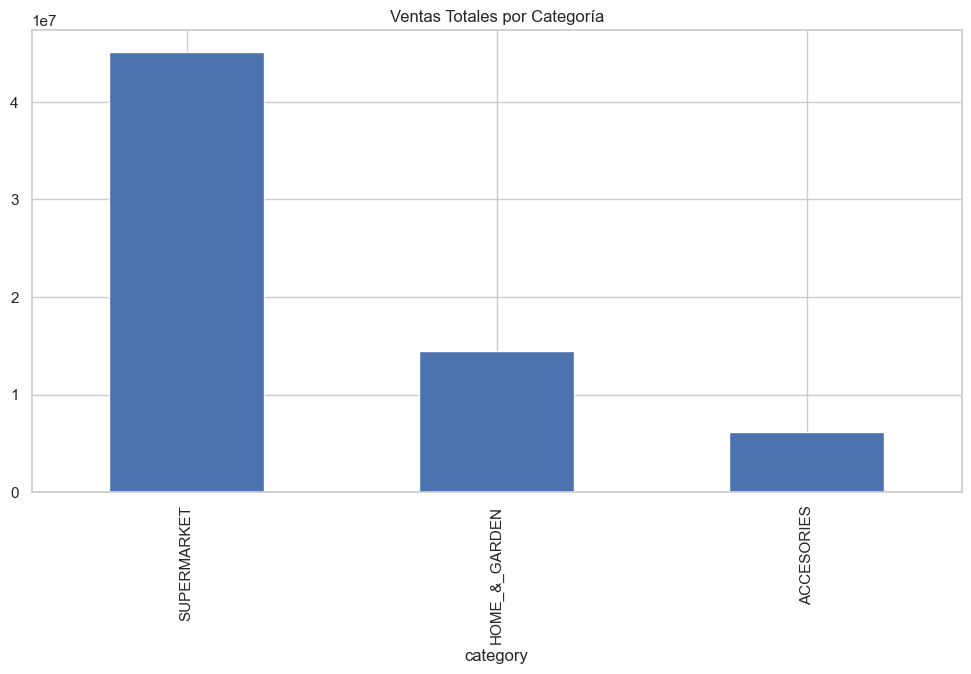

category
SUPERMARKET      45089939
HOME_&_GARDEN    14480670
ACCESORIES        6124800
dtype: int64

In [12]:
category_sales = sales.groupby("category")[day_cols].sum().sum(axis=1).sort_values(ascending=False)

category_sales.plot(kind='bar', title="Ventas Totales por Categoría")
plt.show()

category_sales

Las categorías de alta rotación (alimentación básica) suelen liderar ventas.

Categorías con menor volumen pueden corresponder a productos estacionales o de compra ocasional.

Este análisis ayuda a definir estrategias de pricing y stock.

## 1️⃣0️⃣ Análisis de Tendencia y Crecimiento Mensual

Analizamos la evolución mensual de ventas para detectar crecimiento,
estacionalidad o posibles periodos de caída en el negocio.

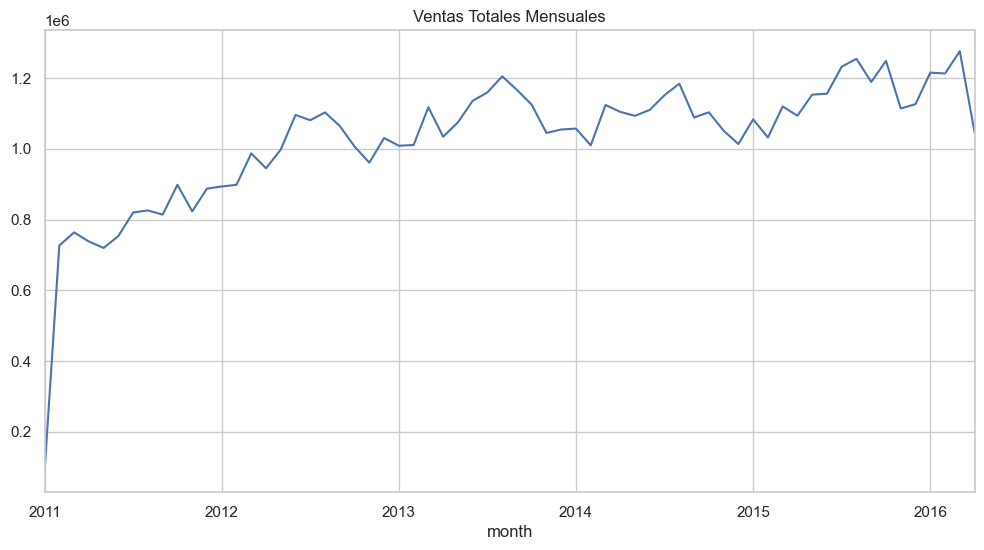

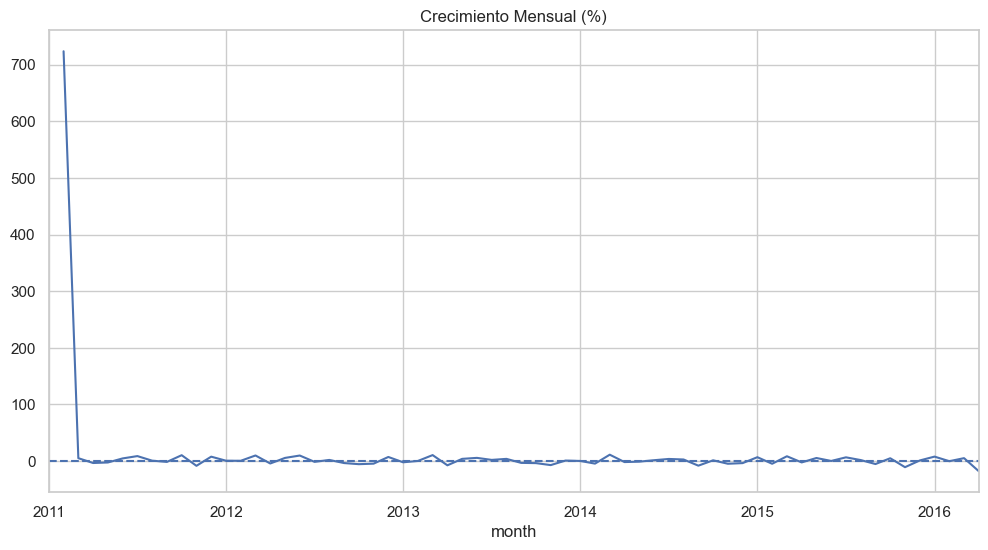

count     63.000000
mean      12.241683
std       91.293427
min      -17.954828
25%       -3.434755
50%        0.716499
75%        5.314248
max      723.900049
Name: total_sales, dtype: float64

In [13]:
# Extraemos mes
df_daily['month'] = df_daily['date'].dt.to_period('M')

# Ventas mensuales
monthly_sales = df_daily.groupby('month')['total_sales'].sum()

# Gráfico ventas mensuales
monthly_sales.plot(title="Ventas Totales Mensuales")
plt.show()

# Crecimiento porcentual mensual
monthly_growth = monthly_sales.pct_change() * 100

monthly_growth.plot(title="Crecimiento Mensual (%)")
plt.axhline(0, linestyle='--')
plt.show()

monthly_growth.describe()


Este análisis permite identificar:

- Tendencias de crecimiento o estancamiento.
- Meses con caídas significativas.
- Posible estacionalidad del negocio.

Si se observan patrones recurrentes (por ejemplo, picos en diciembre),
podría deberse a eventos estacionales o campañas comerciales.

## 1️⃣1️⃣ Análisis de Concentración de Ventas (Regla 80/20)

Evaluamos si un pequeño porcentaje de productos genera la mayor parte de las ventas.
Este análisis es clave para optimización de catálogo e inventario.

C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\4187323918.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_sales_total = sales.groupby("item")[day_cols].sum().sum(axis=1)


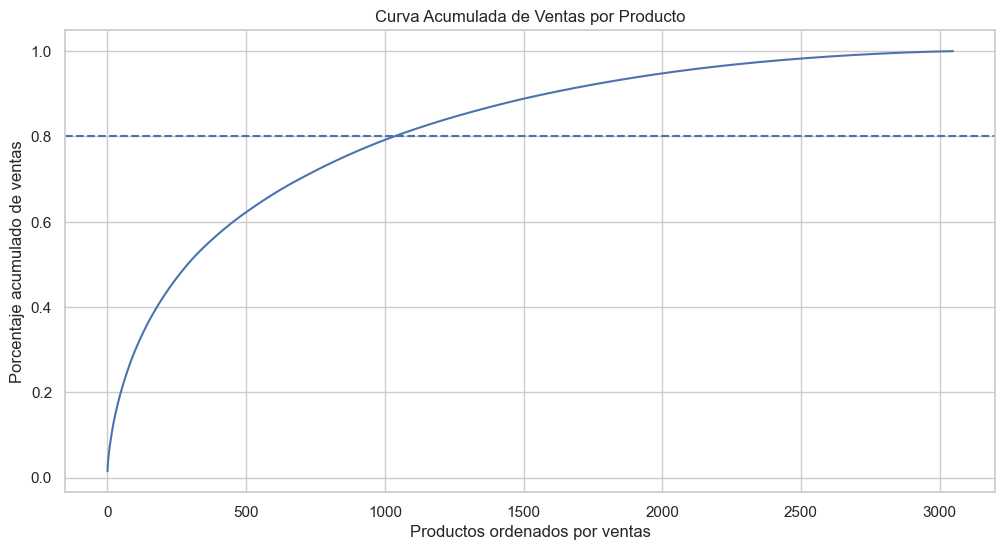

np.float64(33.879960642833716)

In [14]:
# Ventas totales por producto
product_sales_total = sales.groupby("item")[day_cols].sum().sum(axis=1)

# Ordenamos de mayor a menor
product_sales_sorted = product_sales_total.sort_values(ascending=False)

# Calculamos acumulado
cumulative_sales = product_sales_sorted.cumsum() / product_sales_sorted.sum()

# Gráfico curva acumulada
plt.plot(cumulative_sales.values)
plt.axhline(0.8, linestyle='--')
plt.title("Curva Acumulada de Ventas por Producto")
plt.xlabel("Productos ordenados por ventas")
plt.ylabel("Porcentaje acumulado de ventas")
plt.show()

# ¿Qué % de productos genera el 80%?
products_80 = (cumulative_sales <= 0.8).sum()
percentage_products = products_80 / len(product_sales_sorted) * 100

percentage_products

Si aproximadamente el 20% de productos genera el 80% de ventas,
el negocio sigue una distribución tipo Pareto.

Implicaciones estratégicas:

- Optimización del catálogo.
- Reducción de costes de almacenamiento.
- Enfoque en productos de alta rotación.
- Identificación de productos candidatos a eliminación.

## 1️⃣2️⃣ Análisis de Volatilidad de la Demanda

Medimos la estabilidad de las ventas diarias utilizando el coeficiente de variación.

In [15]:
daily_std = df_daily['total_sales'].std()
daily_mean = df_daily['total_sales'].mean()

coef_variation = daily_std / daily_mean

coef_variation

np.float64(0.21390713375405734)

Un coeficiente de variación alto indica demanda inestable,
lo que puede generar problemas de stock o sobreinventario.

Este análisis es especialmente relevante para:

- Modelos predictivos.
- Planificación de inventario.
- Estrategias de abastecimiento.


## 1️⃣3️⃣ Unir ventas con calendario


En este paso se transforman los datos de ventas desde formato ancho a formato largo y posteriormente
se unen con la tabla de calendario. Esto permite que cada registro de venta tenga asociada su fecha,
evento o información temporal correspondiente.

In [16]:
# Pasar ventas a formato largo
sales_long = sales.melt(
    id_vars=["id","item","category","store_code"],
    var_name="d",
    value_name="sales"
)

sales_long.head()

sales_long = sales_long.merge(calendar, on="d", how="left")

sales_long["date"] = pd.to_datetime(sales_long["date"])

sales_long.head()

,id,item,category,store_code,d,sales,date,weekday,weekday_int,event,d_num
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,NYC_1,department,ACCESORIES_1,NaT,NaN,NaN,NaN,NaN
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,NYC_1,department,ACCESORIES_1,NaT,NaN,NaN,NaN,NaN
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,NYC_1,department,ACCESORIES_1,NaT,NaN,NaN,NaN,NaN
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,NYC_1,department,ACCESORIES_1,NaT,NaN,NaN,NaN,NaN
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,NYC_1,department,ACCESORIES_1,NaT,NaN,NaN,NaN,NaN


# Por qué se realiza
Trabajar en formato largo facilita el análisis de series temporales y permite relacionar cada venta
con variables del calendario como festivos, días especiales o temporadas.

# Resultado que podemos apreciar
Gracias a esta unión podemos analizar cómo cambian las ventas según el día, el evento o el periodo
del año. Esto permite detectar patrones de consumo y entender mejor el comportamiento del mercado.

## 1️⃣4️⃣ Análisis por subcategorías



Se convierten las ventas a formato numérico y se agrupan los datos por subcategorías de producto
para analizar el comportamiento de ventas dentro de cada grupo.

subcategory
3    32372076.0
&    14480670.0
1    10684501.0
2     8158162.0
Name: sales, dtype: float64


<Axes: title={'center': 'Ventas por Subcategoría'}, xlabel='subcategory'>

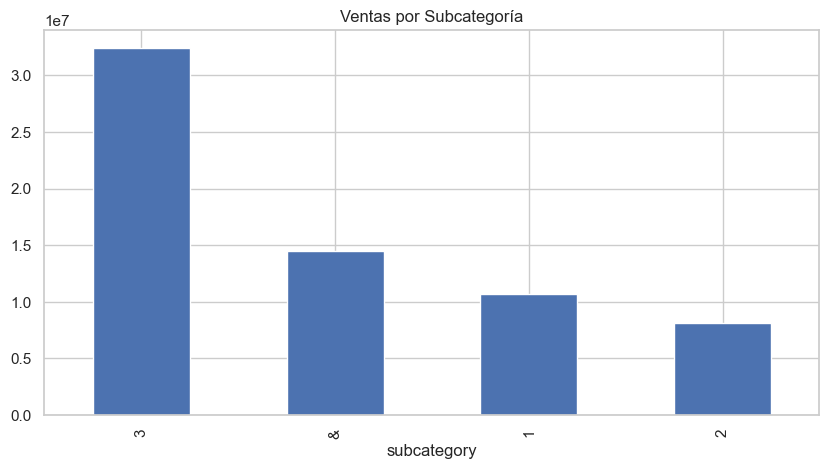

In [17]:
# Convertir sales a número
sales_long["sales"] = pd.to_numeric(sales_long["sales"], errors="coerce")

# Crear subcategoría desde el nombre del item
sales_long["subcategory"] = sales_long["item"].str.split("_").str[1]

# Ventas por subcategoría
subcategory_sales = (
    sales_long.groupby("subcategory")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_sales.head(10))

subcategory_sales.head(10).plot(kind="bar", figsize=(10,5), title="Ventas por Subcategoría")


# Por qué se realiza
Este análisis permite identificar qué tipos de productos tienen mayor demanda dentro de cada
categoría general.

# Resultado que podemos apreciar
Podemos observar qué subcategorías concentran la mayor parte de las ventas, permitiendo identificar
los productos más relevantes para el negocio.

## 1️⃣5️⃣ Análisis de productos por tienda

Se agrupan las ventas por tienda y producto para calcular cuáles son los productos más vendidos
en cada establecimiento.


In [18]:
store_product_sales = (
    sales_long.groupby(["store_code","item"])["sales"]
    .sum()
    .reset_index()
)

# Top productos por tienda
top_products_store = (
    store_product_sales
    .sort_values(["store_code","sales"], ascending=[True, False])
    .groupby("store_code")
    .head(10)
)

top_products_store

C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\2862083267.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_long.groupby(["store_code","item"])["sales"]
C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\2862083267.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("store_code")


,store_code,item,sales
2810,BOS_1,SUPERMARKET_3_586,112454.0
2314,BOS_1,SUPERMARKET_3_090,93684.0
2779,BOS_1,SUPERMARKET_3_555,69516.0
2476,BOS_1,SUPERMARKET_3_252,56294.0
2811,BOS_1,SUPERMARKET_3_587,48277.0
...,...,...,...
29983,PHI_3,SUPERMARKET_3_318,54770.0
30378,PHI_3,SUPERMARKET_3_714,54755.0
30346,PHI_3,SUPERMARKET_3_681,48163.0
29785,PHI_3,SUPERMARKET_3_120,43376.0


import seaborn as sns
import matplotlib.pyplot as plt

top_store_sales = sales_long.groupby("store_code")["sales"].sum().reset_index()

sns.barplot(data=top_store_sales, x="store_code", y="sales")
plt.title("Ventas Totales por Tienda")
plt.show()


# Por qué se realiza
Cada tienda puede tener comportamientos de compra distintos dependiendo de la localización o
preferencias de los clientes.

# Resultado que podemos apreciar
Se identifican los productos estrella de cada tienda, lo que puede ayudar a optimizar inventario,
promociones y estrategias comerciales.

## 1️⃣6️⃣ correlaciones 

Se analiza la relación entre el precio de los productos y las ventas utilizando una muestra del
dataset y calculando la correlación entre ambas variables.

In [19]:
sales_sample = sales_long.sample(100000, random_state=42)

In [20]:
sales_grouped = (
    sales_sample.groupby(["item","store_code"])["sales"]
    .mean()
    .reset_index()
)

C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\3268103360.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_sample.groupby(["item","store_code"])["sales"]


In [21]:
prices_grouped = (
    prices.groupby(["item","store_code"])["sell_price"]
    .mean()
    .reset_index()
)

In [22]:
sales_prices = sales_grouped.merge(
    prices_grouped,
    on=["item","store_code"],
    how="left"
)

In [23]:
corr = sales_prices[["sales","sell_price"]].corr()
print(corr)

               sales  sell_price
sales       1.000000   -0.144365
sell_price -0.144365    1.000000


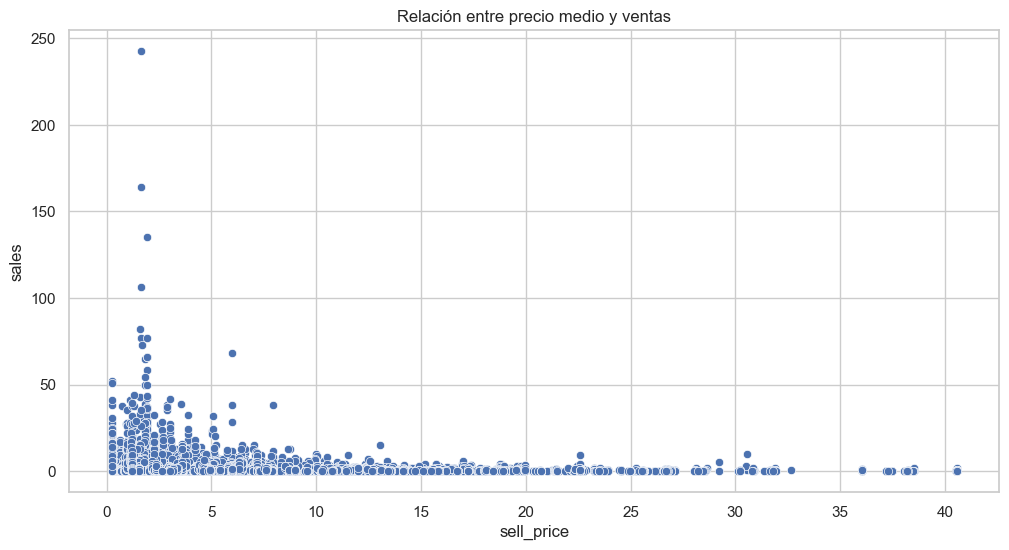

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=sales_prices, x="sell_price", y="sales")
plt.title("Relación entre precio medio y ventas")
plt.show()

Se utiliza una muestra del dataset debido al gran tamaño de sales_long
(más de 50 millones de registros) para evitar problemas de memoria.



# Por qué se realiza
El dataset es muy grande (más de 50 millones de registros), por lo que se usa una muestra para
reducir el tiempo de procesamiento sin perder representatividad.

# Resultado que podemos apreciar
El análisis permite observar si existe relación entre el precio y la cantidad vendida. Por ejemplo,
podemos detectar si precios más altos reducen las ventas o si ciertos productos mantienen demanda
incluso con precios elevados.

## 1️⃣7️⃣ Comparación días normales vs festivos

Se comparan las ventas entre días normales y días en los que existe algún evento o festivo.

In [25]:
sales_sample = sales_long.head(100000)

sales_sample["is_event"] = sales_sample["event"].notna()

event_sales = (
    sales_sample.groupby("is_event")["sales"]
    .mean()
    .reset_index()
)

event_sales["is_event"] = event_sales["is_event"].map({
    True: "Festivo",
    False: "Normal"
})

event_sales

C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\3237726632.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_sample["is_event"] = sales_sample["event"].notna()


,is_event,sales
0,Normal,1.24197


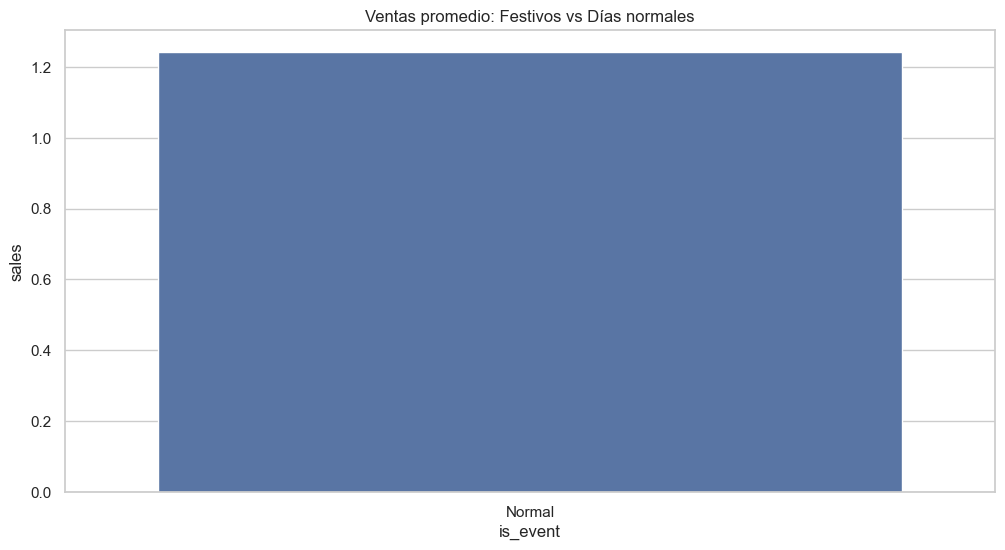

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=event_sales, x="is_event", y="sales")
plt.title("Ventas promedio: Festivos vs Días normales")
plt.show()

Debido al gran tamaño del dataset (más de 50 millones de registros),se utiliza una parte del dataset para realizar el análisis exploratorio
y evitar problemas de memoria.

# Por qué se realiza
Los eventos y festivos suelen generar cambios en el comportamiento de compra de los consumidores.

# Resultado que podemos apreciar
Se puede observar si las ventas aumentan significativamente en días festivos o eventos especiales,
lo que ayuda a planificar promociones o reforzar inventario en esas fechas.

## 2️⃣ Clustering

2️⃣1️⃣ Crear features para clustering

Se generan nuevas variables agregadas por producto, como la media, desviación estándar y suma de
ventas.

In [27]:
item_features = (
    sales_long.groupby("item")
    .agg({
        "sales":["mean","std","sum"]
    })
)

item_features.columns = ["avg_sales","std_sales","total_sales"]
item_features = item_features.fillna(0)

item_features.head()

C:\Users\Angela\AppData\Local\Temp\ipykernel_13644\358516813.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_long.groupby("item")


,avg_sales,std_sales,total_sales
item,,,
ACCESORIES_1_001,0.213957,0.576033,4093.0
ACCESORIES_1_002,0.264454,0.593988,5059.0
ACCESORIES_1_003,0.075013,0.323133,1435.0
ACCESORIES_1_004,2.047831,2.668301,39175.0
ACCESORIES_1_005,0.764297,1.225230,14621.0


# Por qué se realiza
Estas variables resumen el comportamiento de cada producto y sirven como base para aplicar técnicas
de aprendizaje no supervisado como clustering.

# Resultado que podemos apreciar
Cada producto queda representado por un conjunto de métricas que describen su comportamiento de
ventas, permitiendo comparar productos entre sí.

2️⃣2️⃣ Normalizar datos

Se normalizan las variables utilizando StandardScaler para que todas tengan una escala comparable.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(item_features)

# Por qué se realiza
Algoritmos como K-Means dependen de distancias entre datos, por lo que es importante que ninguna
variable tenga más peso que otra debido a su escala.

# Resultado que podemos apreciar
Las variables quedan centradas y escaladas, lo que permite que el algoritmo de clustering funcione
correctamente.

2️⃣3️⃣ Aplicar K-Means

Se aplica el algoritmo K-Means para agrupar los productos en distintos clusters según su
comportamiento de ventas.

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

item_features["cluster"] = kmeans.fit_predict(X_scaled)

item_features.head()

,avg_sales,std_sales,total_sales,cluster
item,,,,
ACCESORIES_1_001,0.213957,0.576033,4093.0,0
ACCESORIES_1_002,0.264454,0.593988,5059.0,0
ACCESORIES_1_003,0.075013,0.323133,1435.0,0
ACCESORIES_1_004,2.047831,2.668301,39175.0,0
ACCESORIES_1_005,0.764297,1.225230,14621.0,0


# Por qué se realiza
El clustering permite identificar grupos de productos con patrones similares de venta.

# Resultado que podemos apreciar
Los productos quedan clasificados en distintos grupos según su rendimiento, lo que ayuda a
identificar productos de alto impacto y productos de baja rotación.

2️⃣4️⃣ Visualización de clusters

Se visualizan los clusters obtenidos mediante un gráfico de dispersión para observar cómo se
agrupan los productos.

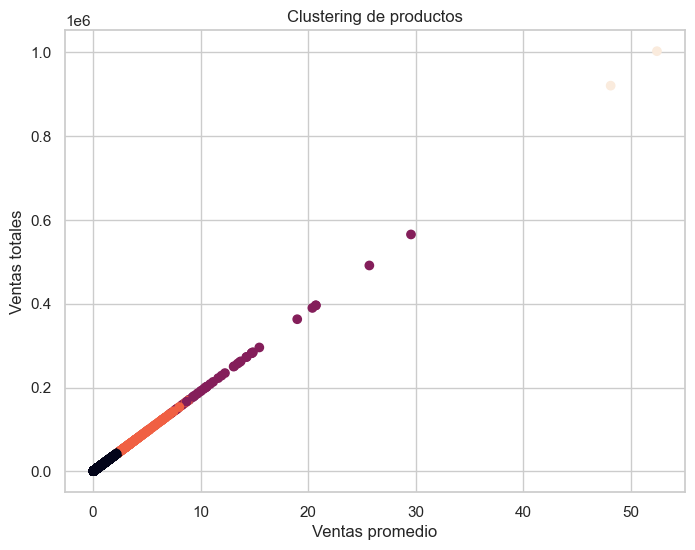

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    item_features["avg_sales"],
    item_features["total_sales"],
    c=item_features["cluster"]
)

plt.xlabel("Ventas promedio")
plt.ylabel("Ventas totales")
plt.title("Clustering de productos")
plt.show()

# Por qué se realiza
La visualización facilita la interpretación de los resultados del clustering.

# Resultado que podemos apreciar
Podemos identificar visualmente los distintos tipos de productos, por ejemplo:
- productos con ventas muy altas
- productos con ventas medias
- productos de baja rotación

Esto ayuda a tomar decisiones estratégicas sobre inventario, promociones o gestión de catálogo.

In [ ]:
# --- CLUSTERING OPTIMIZADO (sin melt, no rompe RAM) ---

day_cols = [c for c in pd_sales.columns if c.startswith("d_")]

df_daily = pd_sales[day_cols].sum().reset_index()
df_daily.columns = ["d", "total_sales"]

df_daily = df_daily.merge(pd_calendar, on="d", how="left")

df_daily["weekday"] = df_daily["weekday"].astype("category").cat.codes
df_daily["event"] = df_daily["event"].fillna("None").astype("category").cat.codes

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df_daily[["total_sales", "weekday", "event"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=6, random_state=42)
df_daily["cluster"] = kmeans.fit_predict(X_scaled)

df_daily.head()